<a href="https://colab.research.google.com/github/ryanglenc/MAT_442/blob/main/MAT_442_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

## 2.4.1 MLE for Random Samples

Given independent samples x1, ..., xn from a distribution with parameter θ, the **likelihood** is

L(θ) = ∏ f(xi; θ)

and the **maximum likelihood estimate** is the θ that maximizes L(θ). In practice we maximize the **log-likelihood**, ℓ(θ) = Σ log f(xi; θ), which turns the product into a sum and has the same maximizer.

For a Normal(μ, σ²) sample, calculus gives closed-form MLEs:
- μ̂ = (1/n) Σ xi (the sample mean)
- σ̂² = (1/n) Σ (xi − μ̂)² (note the divisor n, not n−1, so this estimate is slightly biased)

For a Bernoulli(p) sample, p̂ = (number of successes) / n.

We'll compute these formulas, then confirm them with SciPy's fitter and with a numerical optimizer.

True parameters:     mu = 5.0, sigma = 2.0
Closed-form MLE:     mu = 4.9185, sigma = 1.8573
scipy.stats.norm.fit: mu = 4.9185, sigma = 1.8573
Numerical optimizer: mu = 4.9185, sigma = 1.8573


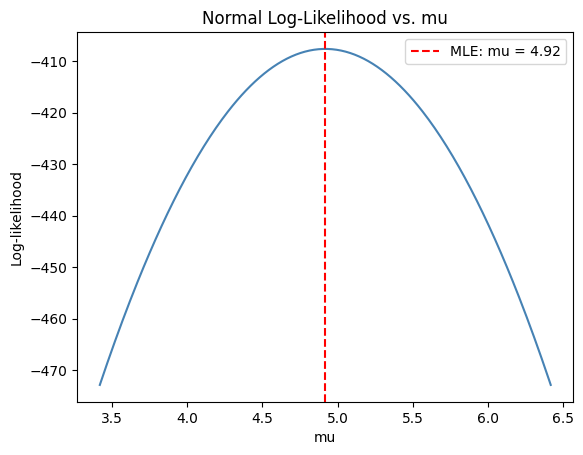

In [2]:
# --- Normal example ---
true_mu, true_sigma = 5.0, 2.0
n = 200
sample = np.random.normal(true_mu, true_sigma, size=n)

# Closed-form MLEs
mu_hat = np.mean(sample)
sigma2_hat = np.mean((sample - mu_hat) ** 2)   # divisor n (MLE), not n-1
print(f"True parameters:     mu = {true_mu}, sigma = {true_sigma}")
print(f"Closed-form MLE:     mu = {mu_hat:.4f}, sigma = {np.sqrt(sigma2_hat):.4f}")

# Check against SciPy's built-in MLE fit
mu_scipy, sigma_scipy = stats.norm.fit(sample)
print(f"scipy.stats.norm.fit: mu = {mu_scipy:.4f}, sigma = {sigma_scipy:.4f}")

# Check with numerical optimization of the negative log-likelihood
def neg_log_likelihood(params, data):
    mu, log_sigma = params            # optimize log(sigma) so sigma stays positive
    sigma = np.exp(log_sigma)
    return -np.sum(stats.norm.logpdf(data, mu, sigma))

result = minimize(neg_log_likelihood, x0=[0.0, 0.0], args=(sample,))
print(f"Numerical optimizer: mu = {result.x[0]:.4f}, sigma = {np.exp(result.x[1]):.4f}")

# Plot the log-likelihood as a function of mu (sigma fixed at its MLE)
mu_grid = np.linspace(mu_hat - 1.5, mu_hat + 1.5, 300)
loglik = [np.sum(stats.norm.logpdf(sample, m, np.sqrt(sigma2_hat))) for m in mu_grid]

plt.plot(mu_grid, loglik, color='steelblue')
plt.axvline(mu_hat, color='red', linestyle='--', label=f'MLE: mu = {mu_hat:.2f}')
plt.xlabel('mu')
plt.ylabel('Log-likelihood')
plt.title('Normal Log-Likelihood vs. mu')
plt.legend()
plt.show()

Heads observed: 74 out of 100
MLE of p: 0.740  (true p = 0.7)


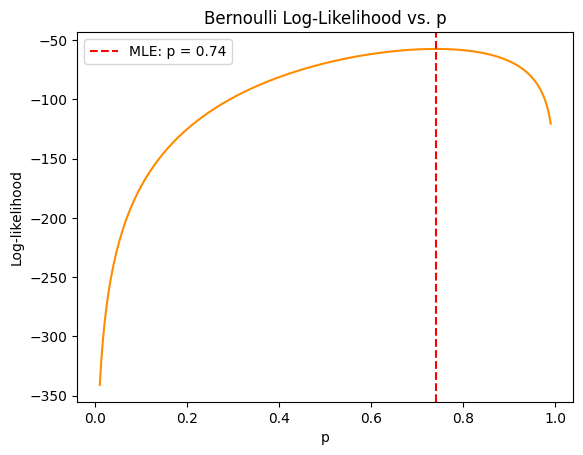

In [3]:
# --- Bernoulli example: estimating a coin's probability of heads ---
true_p = 0.7
flips = np.random.binomial(1, true_p, size=100)

p_hat = flips.mean()   # MLE = (# successes) / n
print(f"Heads observed: {flips.sum()} out of {len(flips)}")
print(f"MLE of p: {p_hat:.3f}  (true p = {true_p})")

# Show that the likelihood peaks at p_hat
p_grid = np.linspace(0.01, 0.99, 300)
loglik_p = flips.sum() * np.log(p_grid) + (len(flips) - flips.sum()) * np.log(1 - p_grid)

plt.plot(p_grid, loglik_p, color='darkorange')
plt.axvline(p_hat, color='red', linestyle='--', label=f'MLE: p = {p_hat:.2f}')
plt.xlabel('p')
plt.ylabel('Log-likelihood')
plt.title('Bernoulli Log-Likelihood vs. p')
plt.legend()
plt.show()

## 2.4.2 Linear Regression

The linear regression model assumes

yi = β0 + β1 xi + εi,  where εi ~ Normal(0, σ²) independently.

Under this model, the log-likelihood of the data is

ℓ(β, σ²) = −(n/2) log(2πσ²) − (1/(2σ²)) Σ (yi − β0 − β1 xi)²

For any fixed σ², maximizing ℓ over β is the same as **minimizing the sum of squared errors**. So the MLE for β is exactly the least-squares solution, given by the normal equations:

β̂ = (XᵀX)⁻¹ Xᵀ y

and the MLE of the noise variance is σ̂² = SSE / n.

We'll generate data from a known line, then recover the parameters three ways (normal equations, `np.linalg.lstsq`, and direct numerical MLE) and check that they agree.

True parameters:        b0 = 2.0, b1 = 3.0
Normal equations:       b0 = 1.5775, b1 = 3.0840
np.linalg.lstsq:        b0 = 1.5775, b1 = 3.0840
Numerical MLE:          b0 = 1.5775, b1 = 3.0840

All three agree: True

MLE of sigma: 1.2689  (numerical MLE: 1.2689, true: 1.5)
R^2 = 0.9829


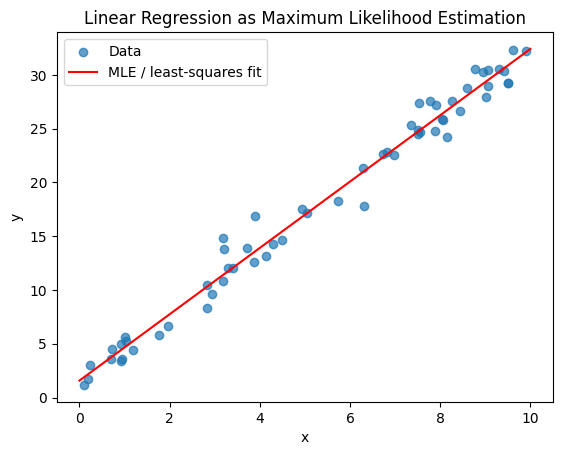

In [4]:
# Generate data from a known line plus Gaussian noise
true_b0, true_b1, true_sigma = 2.0, 3.0, 1.5
n = 60
x = np.random.uniform(0, 10, size=n)
y = true_b0 + true_b1 * x + np.random.normal(0, true_sigma, size=n)

# Design matrix: column of ones (intercept) + x
X = np.column_stack((np.ones(n), x))

# Method 1: normal equations
beta_normal = np.linalg.solve(X.T @ X, X.T @ y)

# Method 2: NumPy least squares
beta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]

# Method 3: direct numerical MLE of (beta0, beta1, sigma)
def neg_log_likelihood_reg(params, X, y):
    b0, b1, log_sigma = params
    sigma = np.exp(log_sigma)
    residuals = y - (b0 + b1 * X[:, 1])
    return -np.sum(stats.norm.logpdf(residuals, 0, sigma))

mle = minimize(neg_log_likelihood_reg, x0=[0.0, 0.0, 0.0], args=(X, y))
beta_mle = mle.x[:2]

print(f"True parameters:        b0 = {true_b0}, b1 = {true_b1}")
print(f"Normal equations:       b0 = {beta_normal[0]:.4f}, b1 = {beta_normal[1]:.4f}")
print(f"np.linalg.lstsq:        b0 = {beta_lstsq[0]:.4f}, b1 = {beta_lstsq[1]:.4f}")
print(f"Numerical MLE:          b0 = {beta_mle[0]:.4f}, b1 = {beta_mle[1]:.4f}")
print("\nAll three agree:", np.allclose(beta_normal, beta_lstsq) and np.allclose(beta_normal, beta_mle, atol=1e-3))

# MLE of the noise variance: SSE / n
y_pred = X @ beta_normal
sse = np.sum((y - y_pred) ** 2)
sigma_hat = np.sqrt(sse / n)
print(f"\nMLE of sigma: {sigma_hat:.4f}  (numerical MLE: {np.exp(mle.x[2]):.4f}, true: {true_sigma})")

# Goodness of fit: R^2
ss_total = np.sum((y - y.mean()) ** 2)
r_squared = 1 - sse / ss_total
print(f"R^2 = {r_squared:.4f}")

# Plot
plt.scatter(x, y, alpha=0.7, label='Data')
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, beta_normal[0] + beta_normal[1] * x_line, color='red', label='MLE / least-squares fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression as Maximum Likelihood Estimation')
plt.legend()
plt.show()